# to add:
1) relationship between topology, edge weights, etc etc as done in GAMM
2) assessment of forward pass test prediction matching original reasonably well

In [7]:
import os


import json
from typing import List, Literal

import numpy as np
import pandas as pd

import scanpy as sc
import pathlib
import torch
import torch.nn as nn

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp 
from scLEMBAS.model.train import TrainSC
from scLEMBAS.model.scl import SignalingModel
import anndata
print(anndata.__version__)

0.11.4


In [8]:
seed = 888
data_path = 'notebooks/McCauley_2024/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)

In [ ]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data

In [ ]:
def get_edge_weights(fold, ensemble_idx):
    fn_trainer =  os.path.join(data_path, 'processed', '{}_fold{}pruning_trainer_actual_ensemble{}.pickle'.format(author, fold, ensemble_idx))
    trainer = io.read_pickled_object(fn_trainer)
    mod = trainer.mod
    
    src, tar = mod.signaling_network.added_edges
    src_real, tar_real = mod.signaling_network.edge_real_edges

    # Extract data
    stochastic_edge_weights = torch.abs(mod.signaling_network.weights[src, tar].detach().cpu().flatten())
    real_edge_weights = torch.abs(mod.signaling_network.weights[src_real, tar_real].detach().cpu().flatten())

    return mod, stochastic_edge_weights, real_edge_weights


all_data_sets_stocastic = []
all_data_sets_real = []
mod_dict = {}
for fold in range(5):
    for ensemble_idx in range(5):
        stochastic_edge_weights, real_edge_weights, mod = get_edge_weights(fold, ensemble_idx)

        all_data_sets_stocastic.append(stochastic_edge_weights)
        all_data_sets_real.append(real_edge_weights)
        mod_dict['fold{}_ensemble{}'.format(fold, ensemble_idx)] = mod


C:\Users\Olof\AppData\Local\Temp\ipykernel_7872\3671498678.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_stoc = np.trapz(1 - y1, x1)
C:\Users\Olof\AppData\Local\Temp\ipykernel_7872\3671498678.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_real = np.trapz(1 - y2, x2)


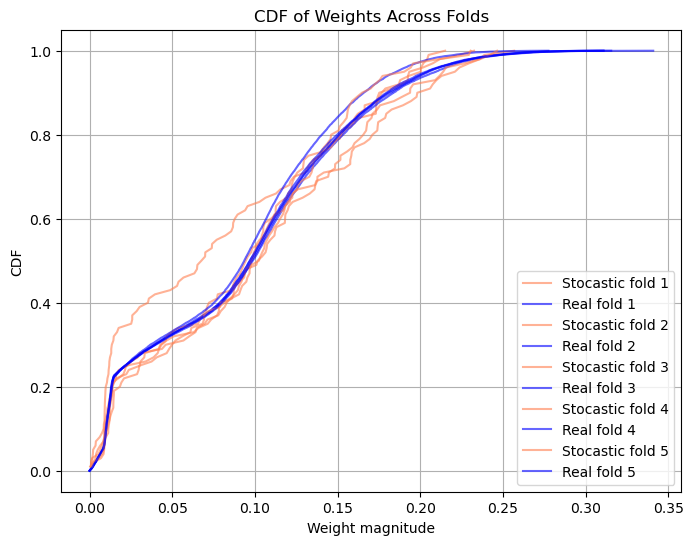

C:\Users\Olof\AppData\Local\Temp\ipykernel_7872\3671498678.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot([np.array(residuals_stocastic)/mean_real, np.array(residuals_real)/mean_real],


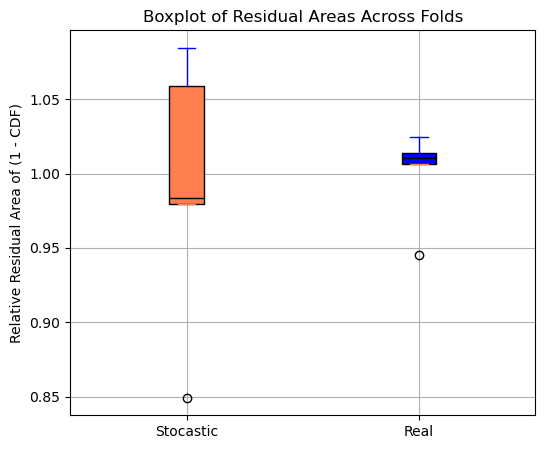

In [ ]:
def compute_cdf(x):
    x_sorted, _ = torch.sort(x)
    y = torch.arange(1, len(x_sorted)+1, dtype=torch.float32) / len(x_sorted)
    return x_sorted.numpy(), y.numpy()


# Store residual areas
residuals_stocastic = []
residuals_real = []

plt.figure(figsize=(8,6))

for i in range(5):
    x1, y1 = compute_cdf(all_data_sets_stocastic[i])
    x2, y2 = compute_cdf(all_data_sets_real[i])
    
    plt.plot(x1, y1, label=f"Stocastic fold {i+1}", color="coral", alpha=0.6)
    plt.plot(x2, y2, label=f"Real fold {i+1}", color="blue", alpha=0.6)
    
    # Compute residual area = integral of (1 - CDF)
    area_stoc = np.trapz(1 - y1, x1)
    area_real = np.trapz(1 - y2, x2)
    
    residuals_stocastic.append(area_stoc)
    residuals_real.append(area_real)

plt.xlabel("Weight magnitude")
plt.ylabel("CDF")
plt.title("CDF of Weights Across Folds")
plt.legend()
plt.grid(True)
plt.show()

mean_real = np.mean(residuals_real)

# Boxplot of residual areas
plt.figure(figsize=(6,5))
bplot = plt.boxplot([np.array(residuals_stocastic)/mean_real, np.array(residuals_real)/mean_real],
                    labels=["Stocastic", "Real"],
                    patch_artist=True)  # enables coloring

# Set colors for boxes
colors = ["coral", "blue"]
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
for whisker, color in zip(bplot['whiskers'], colors*2):
    whisker.set_color(color)
for cap, color in zip(bplot['caps'], colors*2):
    cap.set_color(color)
for median in bplot['medians']:
    median.set_color("black")

plt.ylabel("Relative Residual Area of (1 - CDF)")
plt.title("Boxplot of Residual Areas Across Folds")
plt.grid(True)
plt.show()